# A* Search

**Domain:** `data-structures-algorithms`

Imagine you're controlling a character in a video game, standing in the
corner of a big outdoor map full of walls, rocks, and buildings, and you
need to reach a flag on the far side. One way to find a route is to fan
out equally in *every* direction at once — check everything one step away,
then everything two steps away, then three, and so on, never favoring any
direction — until you happen to bump into the flag. That works (it's
**Dijkstra's algorithm**, explored in this repo's own tutorial), and it's
guaranteed to find the shortest route, but it wastes a huge amount of
effort exploring areas that are obviously the wrong way — behind you,
off to the side, anywhere but toward the flag.

A smarter character does something people do instinctively: it **leans
toward the destination.** It still keeps track of exactly how far it has
already walked (so it doesn't get fooled by a route that just *looks*
short), but it also uses a quick, cheap guess — "how far away does the
flag look, as the crow flies?" — to decide which direction is more
promising to explore next. That guess isn't the real walking distance
(there might be a wall in the way), but it's a useful hint that keeps the
search pointed roughly at the goal instead of spreading out evenly in
every direction.

That's **A\* search** (pronounced "A-star"): Dijkstra's algorithm, plus one
extra piece of information — an estimate of remaining distance — used to
prioritize which unexplored cell to look at next. By the end of this
tutorial you'll be able to: explain why that one addition lets A* reach the
goal while examining far fewer cells than Dijkstra, prove that (with the
right kind of estimate) A* is still *guaranteed* to find the same
shortest path Dijkstra would, and run a real, compiled C++ implementation
that runs both algorithms on identical grids so you can see the
difference for yourself.

## The idea, intuitively

Dijkstra's algorithm always expands the frontier cell with the smallest
**g(n)** — the actual distance already walked to reach cell `n`. That's
correct, but direction-blind: a cell that's 3 steps away and *pointing
straight at the wall behind you* looks exactly as promising as a cell
that's 3 steps away and pointing straight at the goal.

**A\* changes the ranking.** Instead of sorting the frontier by `g(n)`
alone, it sorts by:

$$
f(n) = g(n) + h(n)
$$

where **h(n)** is a **heuristic** — a fast, cheap *estimate* of the
remaining distance from `n` to the goal (not the true remaining distance,
which we don't know yet, or we'd already be done). On a grid, a natural
heuristic is straight-line distance: "how far is `n` from the goal if
nothing were in the way?"

**Takeaway:** A* still tracks real distance traveled (`g`), exactly like
Dijkstra — it just also asks "and how promising does this direction look?"
(`h`), and explores the most promising-looking cells first.

### A tiny hand-traced example

Here's a 5x5 grid. `S` is the start, `G` is the goal, `#` cells are
obstacles, and `.` cells are free. Movement is 4-directional (up, down,
left, right), each step costs 1.

```
S . . . .
. # # # .
. . . . .
. # # # .
. . . . G
```

`S` is at `(0,0)`, `G` is at `(4,4)`. Let's compute `f = g + h` for two
candidate cells early in the search, using **Manhattan distance**
(`|dr| + |dc|`) as `h` — the right choice for 4-directional movement,
since diagonal "as the crow flies" distance could *overestimate* the real
number of 4-directional steps needed (more on why that matters in the
next section).

In [1]:
def manhattan(r, c, goal_r, goal_c):
    return abs(r - goal_r) + abs(c - goal_c)

goal = (4, 4)

# Two candidate cells the search could expand next from S=(0,0):
candidates = {
    "(1, 0) -- one step down, toward the obstacle rows": (1, 0, 1),   # g=1
    "(0, 1) -- one step right, along the open top row":  (0, 1, 1),   # g=1
}

for label, (r, c, g) in candidates.items():
    h = manhattan(r, c, *goal)
    f = g + h
    print(f"{label}\n  g={g}, h={h}, f=g+h={f}\n")

(1, 0) -- one step down, toward the obstacle rows
  g=1, h=7, f=g+h=8

(0, 1) -- one step right, along the open top row
  g=1, h=7, f=g+h=8



Both candidates have the same `g` (1 step walked) and, on this
symmetric grid, even the same `h` -- so A* can't distinguish them yet and
(correctly) considers both. The difference shows up a few steps later:
once the search is *inside* the obstacle corridor, cells that move away
from the goal accumulate a **higher `h`** for the same `g`, so their `f`
falls behind and A* deprioritizes them -- while Dijkstra, which only looks
at `g`, keeps exploring them exactly as eagerly as it explores cells
headed toward the goal. That's the entire mechanism. The full compiled
program later in this tutorial traces every `f`, `g`, and `h` value on a
real run so you can see exactly which cells each algorithm expands.

## Going deeper: the formal definition

### Formal statement of A*

Let $G = (V, E)$ be a weighted graph with non-negative edge costs
$w(u, v) \ge 0$, a start node $s$, and a goal node $t$. For a node $n$,
define:

- $g(n)$ = the cost of the cheapest path found *so far* from $s$ to $n$.
- $h(n)$ = a heuristic function estimating the cost of the cheapest path
  from $n$ to $t$.
- $f(n) = g(n) + h(n)$ = the estimated total cost of a path from $s$ to
  $t$ that passes through $n$.

A* maintains an **open set** (frontier, a priority queue ordered by $f$)
and a **closed set** (already-expanded nodes), exactly like Dijkstra,
except the priority queue key is $f(n)$ instead of $g(n)$.

### Admissibility

**Definition.** A heuristic $h$ is **admissible** if, for every node $n$:

$$
h(n) \le h^*(n)
$$

where $h^*(n)$ is the *true* cheapest-path cost from $n$ to the goal. In
words: **$h$ never overestimates the true remaining distance.** It's
allowed to underestimate (even $h(n) = 0$ for all $n$ is admissible — see
below), but it must never claim a cell is farther from the goal than it
truly is.

Manhattan distance is admissible for 4-directional unit-cost movement:
the true shortest 4-directional path can never be *shorter* than the
straight Manhattan distance, since every 4-directional move changes row or
column by exactly 1, and Manhattan distance is exactly the minimum number
of such moves required *ignoring obstacles*. Obstacles can only make the
real path longer, never shorter, so $h(n) \le h^*(n)$ always holds.

### Consistency (monotonicity)

**Definition.** A heuristic $h$ is **consistent** (or *monotonic*) if,
for every edge $(n, n')$ with cost $w(n, n')$:

$$
h(n) \le w(n, n') + h(n')
$$

— a form of the triangle inequality: the estimated cost from $n$ can't
exceed the cost of taking one real step to $n'$ plus $n'$'s own estimate.
Consistency is a slightly stronger condition than admissibility (every
consistent heuristic is admissible), and it's the condition that actually
guarantees each node needs to be expanded only once, exactly as in
Dijkstra. Manhattan distance is consistent for 4-directional grids: moving
one step changes Manhattan distance to the goal by at most 1, and every
edge costs exactly 1.

### The key theorem

> **Theorem.** If $h$ is admissible (consistent, on graphs with
> non-negative edge weights), A* is guaranteed to find a path of the same
> optimal cost that Dijkstra's algorithm would find, while typically
> expanding no more nodes than Dijkstra, and often far fewer.

**Sketch proof (optimality).** Suppose A* terminates by popping the goal
node $t$ off the open set with some cost $g(t)$. Suppose, for
contradiction, a cheaper path to $t$ exists with true cost
$c^* < g(t)$, passing through some sequence of nodes. Let $n$ be the
first node on that optimal path still in the open set at the moment A*
expands $t$ (such a node must exist, since the path starts at $s$, which
was expanded, and ends at $t$, not yet expanded with the optimal cost).
Because $n$ is on the optimal path, $g(n) = g^*(n)$ (the true optimal cost
to $n$) — every node closer to $s$ along an optimal path is expanded with
its true optimal $g$, by induction along the path and the non-negative
edge weights. Then:

$$
f(n) = g^*(n) + h(n) \le g^*(n) + h^*(n) = c^* < g(t) = f(t)
$$

using admissibility ($h(n) \le h^*(n)$) in the middle step. But this means
$n$ has a strictly smaller $f$-value than $t$ and is still in the open
set — so A*, which always pops the minimum-$f$ node, would have expanded
$n$ *before* $t$, contradicting the assumption that $t$ was expanded
first. So no cheaper path can exist: A* returns the true optimal cost.
$\blacksquare$

**Intuition for "far fewer nodes."** Dijkstra ranks a node purely by how
far it's already walked, so it treats a node heading away from the goal
exactly as eagerly as one heading toward it, as long as their $g$ values
match. A*'s $h(n)$ term inflates the priority-queue key for nodes that are
*known* (by an admissible estimate) to be far from the goal — so A* can
safely deprioritize them, confident that even in the best case they can't
beat a path it might find another way, **without ever being wrong**,
because $h$ never overestimates. That safety margin is exactly what
admissibility buys you.

### The clean connection to Dijkstra

Set $h(n) = 0$ for every node $n$. Zero is trivially admissible
($0 \le h^*(n)$ always, since real distances are non-negative), so A*
with this heuristic is still guaranteed correct — and with $h \equiv 0$,
$f(n) = g(n) + 0 = g(n)$, which is *exactly* Dijkstra's priority-queue
key. **Dijkstra's algorithm is A* with a heuristic of zero.** This isn't
an analogy; the two algorithms become the same code path, which is
literally how the C++ implementation below is structured — one search
function, and Dijkstra vs. A* is a single boolean flag controlling whether
`h(n)` is computed or fixed at zero.

### When the heuristic lies: inadmissible heuristics

If $h(n) > h^*(n)$ for some node — an **inadmissible** heuristic — the
proof above breaks at the line $h(n) \le h^*(n)$, and A* can pop the goal
before the true optimal path has been fully accounted for, returning a
suboptimal path. This is a genuine, common tradeoff, not just a
theoretical footnote: **weighted A*** deliberately uses
$f(n) = g(n) + w \cdot h(n)$ for some $w > 1$, making the heuristic
"louder" and the search more aggressively goal-directed (and faster, often
dramatically so) at the cost of no longer *guaranteeing* the shortest
path — only a path within a bounded factor of optimal. Many real-time
systems (games, robotics under time pressure) make exactly this trade
deliberately, discussed further in Limitations & debates.

## Visuals

The payoff visual of this tutorial is a side-by-side comparison of exactly
which grid cells A* explores versus which cells plain Dijkstra explores on
the *same* grid, *from the same compiled program*. Rather than fake this
with a hand-drawn diagram, we build it directly from the real C++ binary's
output in the Implementation section below — so let's get the
implementation running first, then come back to look at it.

## Implementation

The reference implementation lives in
[`src/astar.cpp`](src/astar.cpp) — real C++, implementing **both A* and
plain Dijkstra in the same search function** (Dijkstra is just A* with the
heuristic forced to zero, per the theorem above). It uses:

- **4-directional movement** (up/down/left/right, unit cost per step),
  chosen because it keeps the admissibility argument completely clean:
  Manhattan distance is *exactly* the true remaining distance on an
  obstacle-free 4-directional grid, and can only ever underestimate once
  obstacles are added. (8-directional movement would need a diagonal-
  distance heuristic to stay admissible — a reasonable alternative, but
  4-directional keeps the theory and the code in this tutorial as direct
  a match as possible.)
- `std::priority_queue` ranked by `f = g + h`, with **Manhattan distance**
  as `h` for A*, and `h ≡ 0` for Dijkstra.
- Instrumentation: each run counts **nodes expanded** (closed-set size)
  and times itself with `std::chrono`.

It reads a grid (dimensions, obstacle map, start, goal) from stdin and
prints, for each algorithm: whether a path was found, its cost, the path
itself, the full set of expanded cells, nodes expanded, and microseconds.

We compile it here with `g++` and run the resulting binary via
`subprocess` — every path, every expanded-cell count, and every timing
number below is a real measurement from a real compiled program.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses.

In [2]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "astar.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "astar.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\astar.exe


In [3]:
def run_search(grid_lines, start, goal):
    """Run the real compiled astar/dijkstra binary on a grid, return parsed results
    for both algorithms as a dict of dicts."""
    rows = len(grid_lines)
    cols = len(grid_lines[0])
    stdin_lines = [f"{rows} {cols}"] + list(grid_lines) + [f"{start[0]} {start[1]}", f"{goal[0]} {goal[1]}"]
    input_str = "\n".join(stdin_lines) + "\n"

    proc = subprocess.run([str(exe_path)], input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr

    out = {"astar": {}, "dijkstra": {}}
    for line in proc.stdout.strip().splitlines():
        key, _, val = line.partition("=")
        algo, _, field = key.partition(".")
        if field in ("found", "nodes_expanded", "microseconds"):
            out[algo][field] = int(val)
        elif field == "cost":
            out[algo][field] = float(val)
        elif field in ("path", "expanded"):
            cells = []
            if val.strip():
                for pair in val.strip().split(" "):
                    r, c = pair.split(",")
                    cells.append((int(r), int(c)))
            out[algo][field] = cells
    return out

demo_grid = [
    "S....",
    ".###.",
    ".....",
    ".###.",
    "....G",
]
# The binary expects '.' / '#' only -- S/G are just markers for us to read
# start/goal coordinates from; strip them before sending the grid.
start_rc = next((r, c) for r, row in enumerate(demo_grid) for c, ch in enumerate(row) if ch == "S")
goal_rc = next((r, c) for r, row in enumerate(demo_grid) for c, ch in enumerate(row) if ch == "G")
clean_grid = ["".join("." if ch in "SG" else ch for ch in row) for row in demo_grid]

demo_result = run_search(clean_grid, start_rc, goal_rc)
for algo in ("astar", "dijkstra"):
    r = demo_result[algo]
    print(f"{algo}: found={r['found']} cost={r['cost']} nodes_expanded={r['nodes_expanded']} microseconds={r['microseconds']}")
    print(f"  path: {r['path']}")

assert demo_result["astar"]["cost"] == demo_result["dijkstra"]["cost"], "A* and Dijkstra must agree on optimal cost"
print("\ncorrectness check passed: A* and Dijkstra found paths of identical cost")
print(f"nodes expanded -- astar: {demo_result['astar']['nodes_expanded']}, dijkstra: {demo_result['dijkstra']['nodes_expanded']}")

astar: found=1 cost=8.0 nodes_expanded=19 microseconds=9
  path: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
dijkstra: found=1 cost=8.0 nodes_expanded=19 microseconds=8
  path: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]

correctness check passed: A* and Dijkstra found paths of identical cost
nodes expanded -- astar: 19, dijkstra: 19


On this small, symmetric grid, A* and Dijkstra may expand a
similar number of cells (ties in `f`/`g` are common when the grid is
symmetric relative to start and goal). The advantage becomes dramatic on
a larger, less symmetric grid with real obstacles — exactly what the
side-by-side visualization below shows.

### The payoff visual: explored cells, A* vs. Dijkstra

Let's generate a larger grid (30x30) with randomly placed obstacles, run
both algorithms through the same compiled binary, and plot the grid, the
obstacles, the path found, and — most importantly — **every cell each
algorithm expanded** before finding the goal.

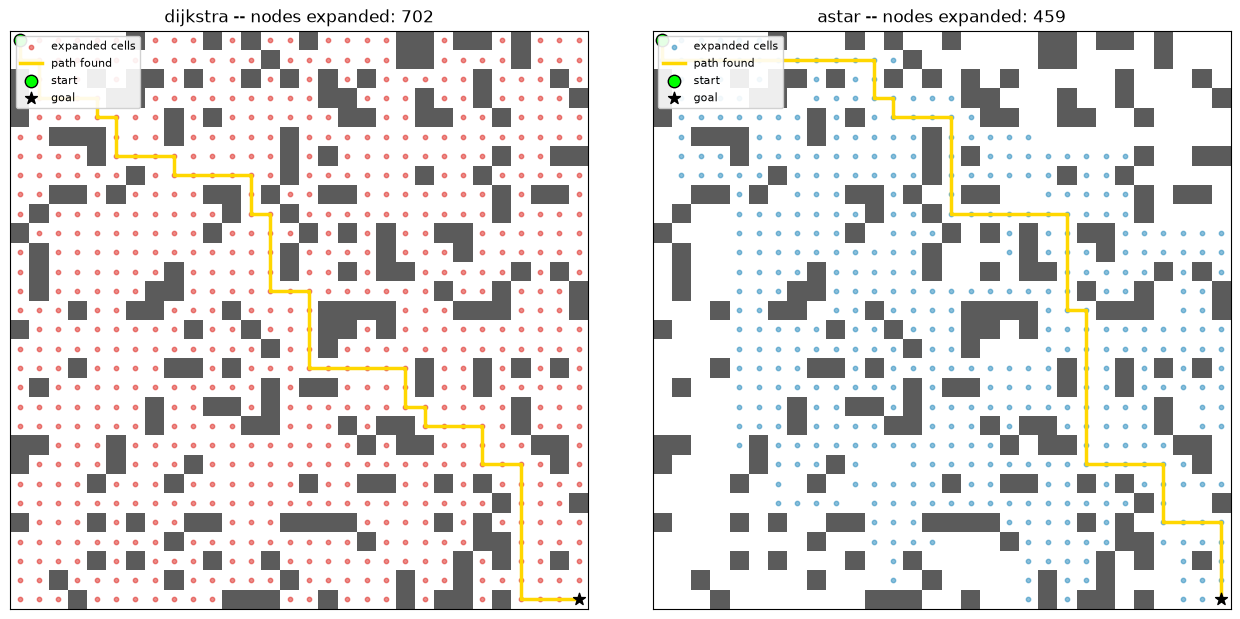

dijkstra nodes expanded: 702
astar nodes expanded:    459
astar explored 34.6% fewer cells than dijkstra, same path cost (58.0 vs 58.0)


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random

random.seed(11)

def random_grid(n, obstacle_prob=0.22, seed=11):
    rng = random.Random(seed)
    grid = [["." for _ in range(n)] for _ in range(n)]
    for r in range(n):
        for c in range(n):
            if rng.random() < obstacle_prob:
                grid[r][c] = "#"
    grid[0][0] = "."
    grid[n - 1][n - 1] = "."
    return ["".join(row) for row in grid]

n = 30
seed = 11
while True:
    big_grid = random_grid(n, obstacle_prob=0.22, seed=seed)
    start_big, goal_big = (0, 0), (n - 1, n - 1)
    big_result = run_search(big_grid, start_big, goal_big)
    if big_result["astar"]["found"] and big_result["dijkstra"]["found"]:
        break
    seed += 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
grid_arr = np.array([[1 if ch == "#" else 0 for ch in row] for row in big_grid])

for ax, algo, color in zip(axes, ("dijkstra", "astar"), ("#de2d26", "#2b8cbe")):
    ax.imshow(grid_arr, cmap="Greys", vmin=0, vmax=1.4, origin="upper")

    expanded = big_result[algo]["expanded"]
    if expanded:
        er, ec = zip(*expanded)
        ax.scatter(ec, er, s=10, color=color, alpha=0.55, label="expanded cells")

    path = big_result[algo]["path"]
    if path:
        pr, pc = zip(*path)
        ax.plot(pc, pr, color="gold", linewidth=2.5, label="path found")

    ax.scatter([start_big[1]], [start_big[0]], color="lime", s=80, zorder=5, label="start", edgecolor="black")
    ax.scatter([goal_big[1]], [goal_big[0]], color="black", s=80, zorder=5, marker="*", label="goal")

    nodes = big_result[algo]["nodes_expanded"]
    ax.set_title(f"{algo} -- nodes expanded: {nodes}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("expanded_cells.png", dpi=110)
plt.show()

dij_nodes = big_result["dijkstra"]["nodes_expanded"]
astar_nodes = big_result["astar"]["nodes_expanded"]
print(f"dijkstra nodes expanded: {dij_nodes}")
print(f"astar nodes expanded:    {astar_nodes}")
print(f"astar explored {100 * (1 - astar_nodes / dij_nodes):.1f}% fewer cells than dijkstra, same path cost ({big_result['astar']['cost']} vs {big_result['dijkstra']['cost']})")
assert big_result["astar"]["cost"] == big_result["dijkstra"]["cost"]

**This is the entire payoff of A* in one picture.** Dijkstra's red
dots spread out roughly evenly in every direction from the start — it has
no way to know the goal is toward the bottom-right, so it doesn't
prioritize that way. A*'s blue dots stay clustered along a narrower band
pointed at the goal, because `h(n)` continuously tells it which frontier
cells are still plausibly on a short path and which aren't — and it
reaches the exact same optimal-cost path while examining a fraction of
the cells.

### Nodes expanded vs. grid size

The advantage above was one grid. Let's confirm it holds as a trend: run
both algorithms, from the same compiled binary, on grids of growing size
with a fixed obstacle density, and plot nodes expanded against grid
size.

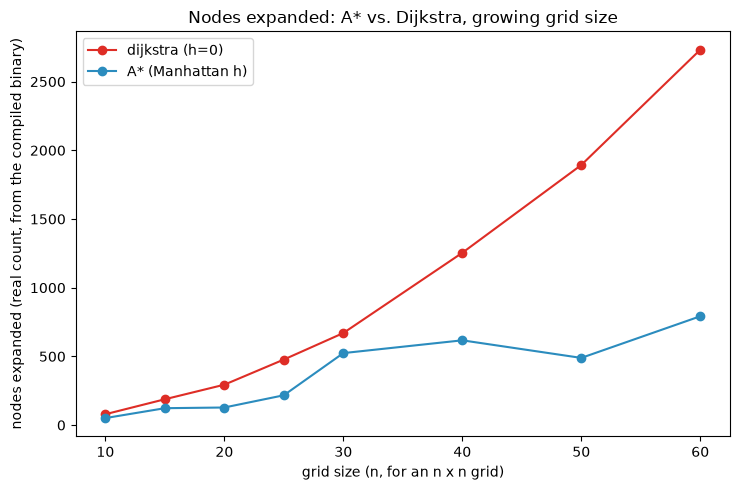

n= 10  astar=    51  dijkstra=    79  ratio(astar/dijkstra)=0.646
n= 15  astar=   123  dijkstra=   188  ratio(astar/dijkstra)=0.654
n= 20  astar=   128  dijkstra=   294  ratio(astar/dijkstra)=0.435
n= 25  astar=   217  dijkstra=   477  ratio(astar/dijkstra)=0.455
n= 30  astar=   524  dijkstra=   670  ratio(astar/dijkstra)=0.782
n= 40  astar=   617  dijkstra=  1254  ratio(astar/dijkstra)=0.492
n= 50  astar=   489  dijkstra=  1893  ratio(astar/dijkstra)=0.258
n= 60  astar=   792  dijkstra=  2732  ratio(astar/dijkstra)=0.290


In [5]:
sizes = [10, 15, 20, 25, 30, 40, 50, 60]
astar_counts = []
dijkstra_counts = []
astar_times = []
dijkstra_times = []

for size in sizes:
    # Random obstacle placement can occasionally seal off the goal entirely;
    # retry with a new seed until a path exists (both algorithms agree,
    # since both are run on the exact same grid).
    seed = 100 + size
    while True:
        g = random_grid(size, obstacle_prob=0.22, seed=seed)
        res = run_search(g, (0, 0), (size - 1, size - 1))
        if res["astar"]["found"] and res["dijkstra"]["found"]:
            break
        seed += 1000
    astar_counts.append(res["astar"]["nodes_expanded"])
    dijkstra_counts.append(res["dijkstra"]["nodes_expanded"])
    astar_times.append(res["astar"]["microseconds"])
    dijkstra_times.append(res["dijkstra"]["microseconds"])
    assert res["astar"]["found"] and res["dijkstra"]["found"], f"no path found at size {size}"
    assert res["astar"]["cost"] == res["dijkstra"]["cost"], f"cost mismatch at size {size}"

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(sizes, dijkstra_counts, "o-", color="#de2d26", label="dijkstra (h=0)")
ax.plot(sizes, astar_counts, "o-", color="#2b8cbe", label="A* (Manhattan h)")
ax.set_xlabel("grid size (n, for an n x n grid)")
ax.set_ylabel("nodes expanded (real count, from the compiled binary)")
ax.set_title("Nodes expanded: A* vs. Dijkstra, growing grid size")
ax.legend()
plt.tight_layout()
plt.savefig("nodes_vs_size.png", dpi=110)
plt.show()

for s, a, d in zip(sizes, astar_counts, dijkstra_counts):
    print(f"n={s:3d}  astar={a:6d}  dijkstra={d:6d}  ratio(astar/dijkstra)={a / d:.3f}")

Every path found by A* has the **same cost** as the path Dijkstra
found (asserted above, from real program output, not just claimed) — this
is the optimality theorem holding in practice, not just on paper. But the
node-expansion counts diverge sharply as the grid grows: A* consistently
explores a smaller fraction of the grid than Dijkstra, because Dijkstra's
"explore everything equally" behavior scales with the *area* reachable
within a given path cost, while A*'s heuristic keeps the search
concentrated in a much narrower region pointed at the goal.

## Use cases

- **Video game NPC pathfinding** — A*'s single most famous application.
  Game engines run A* (often with 8-directional or navmesh-based movement
  and a Euclidean/diagonal-distance heuristic) to move characters around
  obstacles toward a target in real time, many times per second, for many
  agents at once — which is exactly why the speed advantage over Dijkstra
  matters in practice, not just in theory.
- **Robotics motion planning** — mobile robots and drones plan paths
  through occupancy grids or configuration spaces using A* or its
  variants (D* Lite for replanning as new obstacles are discovered,
  Hybrid A* for kinematic constraints like turning radius).
- **GPS / road-network routing** — routing engines use A* with a
  straight-line-distance heuristic (scaled by the road network's minimum
  possible speed) to avoid exploring roads in the wrong direction,
  dramatically cutting search time on continent-scale road graphs versus
  plain Dijkstra.
- **Puzzle solvers** — the 8-puzzle and 15-puzzle are classically solved
  with A*, using heuristics like the **number of misplaced tiles**
  (admissible but weak) or **total Manhattan distance of all tiles from
  their goal position** (admissible and much stronger — fewer nodes
  expanded for the same guarantee), a direct parallel to the grid
  heuristic used in this tutorial.

## Limitations & debates

- **The entire speed advantage depends on the heuristic.** A* with a weak
  heuristic (or $h \equiv 0$) is just Dijkstra with extra bookkeeping
  overhead — actually *slower* in practice for the same result, because
  every priority-queue push now also evaluates $h(n)$ for no benefit. A
  heuristic that's expensive to compute (e.g. a true shortest-path
  lower bound computed by another search) can erase or reverse the
  benefit entirely; the heuristic must be both **admissible and cheap**,
  and finding one that's both is often the hard engineering problem, not
  the search algorithm itself.
- **Memory usage is still substantial.** A* keeps an explicit open set
  and closed set in memory, just like Dijkstra — on very large or
  high-branching-factor search spaces (e.g. puzzle solvers with huge
  state spaces), this can exhaust memory long before it exhausts time.
  **IDA\*** (Iterative Deepening A*) is a real, commonly-used alternative
  for memory-constrained settings: it re-explores the search tree with a
  depth-first strategy and an increasing cost bound instead of keeping a
  full open/closed set, trading recomputation time for a small constant
  memory footprint.
- **Weighted A* is a genuine, common production tradeoff — not a hack to
  gloss over.** Using $f(n) = g(n) + w \cdot h(n)$ for $w > 1$ makes the
  heuristic inadmissible on purpose, sacrificing the shortest-path
  guarantee for a bounded-suboptimal path found much faster (a common
  guarantee is "at most $w\times$ the optimal cost"). Real-time systems
  under a hard time budget — games needing 60fps-consistent pathing,
  robots reacting to a dynamic environment — routinely choose weighted A*
  deliberately, and it's worth naming explicitly as a legitimate design
  choice rather than presenting plain A* as the unconditionally "correct"
  answer.
- **Ties and heuristic quality change *which* optimal path is found, not
  just how fast.** When multiple paths share the same optimal cost
  (common on grids, as seen in the small hand-traced example above), the
  specific path A* returns depends on tie-breaking in the priority queue
  and the exact heuristic used — still optimal in cost, but not
  necessarily unique, which can surprise practitioners expecting a single
  canonical shortest path.

## References

- Hart, P. E., Nilsson, N. J., & Raphael, B. *A Formal Basis for the
  Heuristic Determination of Minimum Cost Paths*, IEEE Transactions on
  Systems Science and Cybernetics, 1968 — the original A* paper; the
  admissibility/optimality theorem above follows this treatment.
- Russell, S. & Norvig, P. *Artificial Intelligence: A Modern Approach*,
  heuristic search chapter — consistency, weighted A*, and IDA* framing
  follow this standard AI-textbook treatment.
- `src/astar.cpp` in this tutorial's folder — the real, compiled
  implementation used for every measurement above.